Imports and simulator check

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from scipy.stats import poisson

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

print("Imports successful — running Qiskit 2.0+ environment.")

#Test AerSimulator functionality by building simple circuit
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

simulator = AerSimulator()

# Transpile and run the circuit
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1000)
result = job.result()
counts = result.get_counts()

print(" Simulator test successful.")
print("Measurement counts (approx):", counts)


Imports successful — running Qiskit 2.0+ environment.
 Simulator test successful.
Measurement counts (approx): {'0': 481, '1': 519}


In [ ]:
# Simulation counts
N_PULSES = 20_000            # number of pulses for BB84 simulation (default 1e4)
TARGET_FINAL_KEY_BITS = 65_536  # target demo final key size (will attempt to produce)

# Decoy intensities (defaults)
MU_SIGNAL = 0.5   # signal intensity (mean photon number)
NU_DECOY  = 0.1   # weak decoy intensity
MU_VAC    = 0.0   # vacuum

INTENSITIES = {
    'signal': MU_SIGNAL,
    'decoy': NU_DECOY,
    'vacuum': MU_VAC
}

INTENSITY_PROBS = {
    'signal': 0.6,
    'decoy': 0.3,
    'vacuum': 0.1
}

# Channel & detector parameters (simple model)
CHANNEL_TRANSMITTANCE = 0.1   # overall transmissivity (0..1)
DETECTOR_EFFICIENCY = 0.1     # detector efficiency (further scaling)
DARK_COUNT_PROB = 1e-5        # probability per pulse of dark count (very small)
QBER_INSTRINSIC = 0.01        # intrinsic optical misalignment error rate

# Eve: toggle PNS (Photon Number Splitting) attack simulation
ENABLE_PNS_ATTACK = True
PNS_KEEP_PROB = 1.0  # if multi-photon, Eve keeps one photon with this prob

# Random seed for reproducibility (change or set to None)
# RANDOM_SEED = 52
# if RANDOM_SEED is not None:
#     random.seed(RANDOM_SEED)
#     np.random.seed(RANDOM_SEED)

print("Environment ready. N_PULSES =", N_PULSES)

Environment ready. N_PULSES = 20000


Decoy state BB84 simulation 

In [3]:
# Poisson sampling for photon numbers given intensity mu
def sample_photon_number(mu: float) -> int:
    # Poisson distribution sample
    # For mu=0 returns 0
    if mu <= 0:
        return 0
    # Use numpy's poisson
    return np.random.poisson(mu)

# Alice prepares a pulse: pick basis, bit, intensity type
def alice_prepare(intensity_probs=INTENSITY_PROBS):
    # intensity choice
    choices = list(intensity_probs.keys())
    probs = list(intensity_probs.values())
    intensity_type = np.random.choice(choices, p=probs)
    mu = INTENSITIES[intensity_type]
    # basis: 'Z' or 'X'
    basis = 'Z' if random.random() < 0.5 else 'X'
    bit = 0 if random.random() < 0.5 else 1
    # photon number (simulated source)
    n_photons = sample_photon_number(mu)
    return {
        'intensity_type': intensity_type,
        'mu': mu,
        'basis': basis,
        'bit': bit,
        'n_photons': n_photons
    }

# Channel model: includes loss, detector efficiency, dark counts, and PNS attack
def channel_and_bob_detection(pulse, enable_pns=ENABLE_PNS_ATTACK):
    n = pulse['n_photons']
    # Eve PNS attack simulation: if multi-photon and PNS enabled, Eve may split and keep one photon
    eve_kept = 0
    if enable_pns and n >= 2:
        if random.random() < PNS_KEEP_PROB:
            # Eve keeps one photon (simulated) and forwards remaining n-1 photons
            # For simplicity, assume she forwards n-1 photons (so Bob sees less photons)
            n_forward = n - 1
            eve_kept = 1
        else:
            n_forward = n
    else:
        n_forward = n

    # Photons reaching Bob after channel transmittance (binomial thinning)
    # For each photon forwarded, it survives the channel with probability CHANNEL_TRANSMITTANCE
    # Instead of per-photon loop, use binomial
    if n_forward > 0:
        survived = np.random.binomial(n_forward, CHANNEL_TRANSMITTANCE)
    else:
        survived = 0

    # Detector clicks: detection probability per surviving photon is DETECTOR_EFFICIENCY
    if survived > 0:
        # if one or more photons survive, chance of at least one detection is 1 - (1 - eff)^survived
        click_prob = 1 - (1 - DETECTOR_EFFICIENCY) ** survived
    else:
        click_prob = 0.0

    # include dark counts
    click_prob = 1 - (1 - click_prob) * (1 - DARK_COUNT_PROB)

    detected = random.random() < click_prob

    # If detected, we simulate Bob's measured bit: with intrinsic misalignment causing errors
    detected_bit = None
    if detected:
        # If there were surviving photons, the correct bit is transmitted with prob (1 - QBER_INSTRINSIC)
        error = (random.random() < QBER_INSTRINSIC)
        if survived == 0 and DARK_COUNT_PROB > 0:
            # dark count: random outcome
            detected_bit = 0 if random.random() < 0.5 else 1
        else:
            # ideally Bob measures Alice's bit when bases match; at measurement we don't know basis yet
            detected_bit = pulse['bit'] ^ (1 if error else 0)

    # Return detection info and whether Eve kept photon
    return {
        'detected': detected,
        'detected_bit': detected_bit,
        'survived_photons': survived,
        'eve_kept': eve_kept
    }

# Bob chooses measurement basis randomly
def bob_measurement():
    return 'Z' if random.random() < 0.5 else 'X'

# Run a single pulse trial end-to-end (Alice -> Channel -> Bob)
def run_single_pulse():
    pulse = alice_prepare()
    bob_basis = bob_measurement()
    chan = channel_and_bob_detection(pulse)
    # record event: whether basis matched, and if detected what bit
    basis_match = (pulse['basis'] == bob_basis)
    return {
        'pulse': pulse,
        'bob_basis': bob_basis,
        'basis_match': basis_match,
        'detected': chan['detected'],
        'detected_bit': chan['detected_bit'],
        'survived_photons': chan['survived_photons'],
        'eve_kept': chan['eve_kept']
    }

print("BB84 helper functions ready.")


BB84 helper functions ready.


simulation and statistics collection

In [4]:
from collections import defaultdict

def run_bb84_simulation(n_pulses=N_PULSES):
    events = []
    for _ in range(n_pulses):
        ev = run_single_pulse()
        events.append(ev)
    return events

events = run_bb84_simulation(N_PULSES)
print(f"Simulated {len(events)} pulses.")

# Aggregate useful stats: per-intensity totals and detections (before sifting)
stats = defaultdict(lambda: {'sent':0, 'detected':0, 'errors':0, 'detected_basis_match':0, 'basis_match_sent':0})
total_detected = 0
total_basis_match = 0
total_key_candidates = 0
total_errors_on_sift = 0

# track true yields per photon-number for analysis (only possible in simulation)
yields_by_n = defaultdict(lambda: {'sent':0, 'detected':0, 'errors':0})

for ev in events:
    p = ev['pulse']
    t = p['intensity_type']
    stats[t]['sent'] += 1
    if ev['detected']:
        stats[t]['detected'] += 1
        total_detected += 1
        # compare detected bit to Alice's bit if available
        if ev['detected_bit'] is not None and ev['detected_bit'] != p['bit']:
            stats[t]['errors'] += 1
    # basis matching stats
    if ev['basis_match']:
        stats[t]['basis_match_sent'] += 1
        if ev['detected']:
            stats[t]['detected_basis_match'] += 1
            total_key_candidates += 1
            # error in sifted key?
            if ev['detected_bit'] != p['bit']:
                total_errors_on_sift += 1

    # true photon-number yields (simulation internal)
    n = p['n_photons']
    yields_by_n[n]['sent'] += 1
    if ev['detected']:
        yields_by_n[n]['detected'] += 1
        if ev['detected_bit'] != p['bit']:
            yields_by_n[n]['errors'] += 1

# Print per-intensity gains and QBER
print("Per-intensity summary:")
for t in ['signal','decoy','vacuum']:
    s = stats[t]
    sent = s['sent']
    det = s['detected']
    det_match = s['detected_basis_match']
    basis_sent = s['basis_match_sent']
    q = det / sent if sent>0 else 0.0
    q_match = det_match / basis_sent if basis_sent>0 else 0.0
    e = (s['errors'] / det) if det>0 else 0.0
    print(f" {t:6s}: sent={sent}, detections={det}, gain(Q)={q:.5f}, sifting-detected={det_match}, sift_rate={q_match:.5f}, error_rate={e:.4f}")

# Global sifted key statistics
sifted_key_len = total_key_candidates
sifted_qber = total_errors_on_sift / sifted_key_len if sifted_key_len>0 else 0.0
print(f"\nSifted key length (basis matched & detected) = {sifted_key_len}")
print(f"Sifted QBER (observed) = {sifted_qber:.4%}")

# Show a few yields_by_n entries (for small n)
print("\nTrue yields by photon-number (n):")
for n in sorted(list(yields_by_n.keys()))[:8]:
    y = yields_by_n[n]
    sent = y['sent']
    det = y['detected']
    err = y['errors']
    print(f" n={n:2d}: sent={sent}, detected={det}, yield={det/sent if sent>0 else 0:.5f}, err_rate={(err/det) if det>0 else 0:.4f}")


Simulated 20000 pulses.
Per-intensity summary:
 signal: sent=11887, detections=27, gain(Q)=0.00227, sifting-detected=14, sift_rate=0.00236, error_rate=0.0000
 decoy : sent=6041, detections=8, gain(Q)=0.00132, sifting-detected=4, sift_rate=0.00131, error_rate=0.0000
 vacuum: sent=2072, detections=0, gain(Q)=0.00000, sifting-detected=0, sift_rate=0.00000, error_rate=0.0000

Sifted key length (basis matched & detected) = 18
Sifted QBER (observed) = 0.0000%

True yields by photon-number (n):
 n= 0: sent=14817, detected=0, yield=0.00000, err_rate=0.0000
 n= 1: sent=4108, detected=27, yield=0.00657, err_rate=0.0000
 n= 2: sent=915, detected=8, yield=0.00874, err_rate=0.0000
 n= 3: sent=143, detected=0, yield=0.00000, err_rate=0.0000
 n= 4: sent=16, detected=0, yield=0.00000, err_rate=0.0000
 n= 5: sent=1, detected=0, yield=0.00000, err_rate=0.0000


Estimate Y_n (yields) and e_n from simulation

In [5]:
 # NOTE: In a real experiment, Alice and Bob only see aggregated Q_mu and E_mu.
# Here we show two things:
#  - True Y_n and e_n computed from the simulated labels (for validation)
#  - A simple estimation by truncating photon-number expansion (n=0..2) and solving linear system
#    using observed Q_mu for the three intensities (signal, decoy, vacuum).

# 1) True values from simulation:
true_Y = {}
true_e = {}
for n, v in yields_by_n.items():
    if v['sent'] > 0:
        true_Y[n] = v['detected'] / v['sent']
        true_e[n] = (v['errors'] / v['detected']) if v['detected'] > 0 else 0.0

print("True Y_n for small n (from simulation labels):")
for n in sorted(true_Y.keys())[:6]:
    print(f" n={n}: Y={true_Y[n]:.6f}, e={true_e.get(n,0):.6f}")

# 2) Observables: compute Q_mu and E_mu for each intensity (these are what Alice/Bob would see)
observables = {}
for t, mu in INTENSITIES.items():
    sent = stats[t]['sent']
    det = stats[t]['detected']
    err = stats[t]['errors']
    Q = det / sent if sent>0 else 0.0
    E = (err / det) if det>0 else 0.0
    observables[t] = {'mu': mu, 'Q': Q, 'E': E}
    print(f"\nObserved for {t}: mu={mu}, Q={Q:.6f}, E={E:.6f}")

# 3) Simple truncated linear solve for Y0, Y1, Y2 using the three intensities:
#    Q(mu) = sum_{n=0..2} P(n|mu) * Y_n  (approx truncating higher n into Y2)
def poisson_pmf(n, mu):
    if mu <= 0:
        return 1.0 if n==0 else 0.0
    return math.exp(-mu) * (mu**n) / math.factorial(n)

# Prepare matrix A and vector b (3x3)
mus = [observables['signal']['mu'], observables['decoy']['mu'], observables['vacuum']['mu']]
Qs  = [observables['signal']['Q'], observables['decoy']['Q'], observables['vacuum']['Q']]

A = np.zeros((3,3))
b = np.array(Qs)
for i, mu in enumerate(mus):
    for n in range(3):
        A[i,n] = poisson_pmf(n, mu)
# Solve A * Y = b for Y0..Y2 (least squares if not exact)
try:
    Y_est, *_ = np.linalg.lstsq(A, b, rcond=None)
    Y_est = np.maximum(Y_est, 0)  # enforce non-negativity approx
    print("\nEstimated (truncated) yields Y0..Y2 from observables (approx):")
    for n in range(3):
        print(f" Y_{n} ≈ {Y_est[n]:.6e}")
    print("\nCompare to true Y_0..Y_2 (where available):")
    for n in range(3):
        print(f" true Y_{n} = {true_Y.get(n, 0.0):.6e}")
except Exception as e:
    print("Estimation failed:", e)

# 4) For e1 (error rate on single-photon pulses): compute true and estimated (simple)
true_e1 = true_e.get(1, None)
print(f"\nTrue e1 (from simulation labels) = {true_e1}")

# Estimated e1 (approx): from E_mu Q_mu = sum P(n|mu) Y_n e_n
# If we use the estimated Y_n and assume e_2 ~ e_1 for truncation, we can approximate e1.
# Here we compute e1_est = (E_mu Q_mu - sum_{n!=1} P(n|mu) Y_n e_n) / (P(1|mu) Y1)
# But since we don't have e_n for higher n, we will compute a crude estimate using the signal intensity.
mu_sig = observables['signal']['mu']
P1_sig = poisson_pmf(1, mu_sig)
EQ = observables['signal']['E'] * observables['signal']['Q']  # E_mu * Q_mu
# Approximate numerator subtracting n=0 (vacuum has no bit info) and use estimated Y2 with e2~observed E
e2_approx = observables['signal']['E']
Y0_est = Y_est[0]
Y1_est = Y_est[1]
Y2_est = Y_est[2]
numer = EQ - (poisson_pmf(0,mu_sig) * Y0_est * 0.0) - (poisson_pmf(2,mu_sig) * Y2_est * e2_approx)
denom = poisson_pmf(1,mu_sig) * max(Y1_est, 1e-12)
e1_est = numer / denom if denom>0 else None
print(f"Estimated (approx) e1 = {e1_est}")

# Print short wrap-up
print("\nNOTE: The estimation above is a simplified demonstration. In a production analysis,")
print("decoy-state parameter estimation uses tighter analytic bounds or linear-programming")
print("techniques. Here we show a direct, simulator-based 'true' value and a simple truncated")
print("reconstruction from observables to compare.")


True Y_n for small n (from simulation labels):
 n=0: Y=0.000000, e=0.000000
 n=1: Y=0.006573, e=0.000000
 n=2: Y=0.008743, e=0.000000
 n=3: Y=0.000000, e=0.000000
 n=4: Y=0.000000, e=0.000000
 n=5: Y=0.000000, e=0.000000

Observed for signal: mu=0.5, Q=0.002271, E=0.000000

Observed for decoy: mu=0.1, Q=0.001324, E=0.000000

Observed for vacuum: mu=0.0, Q=0.000000, E=0.000000

Estimated (truncated) yields Y0..Y2 from observables (approx):
 Y_0 ≈ 0.000000e+00
 Y_1 ≈ 1.642206e-02
 Y_2 ≈ 0.000000e+00

Compare to true Y_0..Y_2 (where available):
 true Y_0 = 0.000000e+00
 true Y_1 = 6.572541e-03
 true Y_2 = 8.743169e-03

True e1 (from simulation labels) = 0.0
Estimated (approx) e1 = 0.0

NOTE: The estimation above is a simplified demonstration. In a production analysis,
decoy-state parameter estimation uses tighter analytic bounds or linear-programming
techniques. Here we show a direct, simulator-based 'true' value and a simple truncated
reconstruction from observables to compare.


Local QRNG using Qiskit Aer simulator (Hadamard single-qubit sampling)
QRNG function (memory-based)

In [13]:
# QRNG: robust version using memory from Aer simulator
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile

def qrng_generate_bits_qiskit(n_bits: int, backend_name='aer_simulator', use_fixed_seed: bool = False):
    """
    Returns a string of '0'/'1' of length n_bits.
    - Uses result.get_memory() to obtain shot-by-shot results (no block-expansion)
    - If use_fixed_seed=True, the simulator run will be seeded (reproducible). Otherwise nondeterministic.
    """
    backend = Aer.get_backend(backend_name)

    # max shots per job to avoid huge runs
    max_shots_per_job = 8192
    bits = []
    remaining = n_bits
    while remaining > 0:
        shots = min(remaining, max_shots_per_job)
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)

        compiled = transpile(qc, backend)

        # Provide seed_simulator only if user wants reproducible runs
        run_kwargs = {"shots": shots, "memory": True}
        if use_fixed_seed:
            # choose a random-ish seed or leave deterministic by passing an int (e.g. 42)
            run_kwargs["seed_simulator"] = 42

        job = backend.run(compiled, **run_kwargs)
        result = job.result()

        # get_memory returns a list of bitstrings (one per shot) preserving shot order
        try:
            mem = result.get_memory()
        except Exception:
            # fallback: if memory not supported, revert to counts but shuffle to avoid blocks
            counts = result.get_counts()
            mem = []
            for bitstr, cnt in counts.items():
                mem.extend([bitstr] * cnt)
            random.shuffle(mem)

        # mem entries like ['0','1','0',...]
        # If format is multi-bit strings, take the last char
        for m in mem:
            bits.append(m[-1])
        remaining -= shots

    return ''.join(bits[:n_bits])


Extract raw sifted key from simulation - bits where basis matched and a detection occurred

In [7]:
def extract_sifted_key(events):
    alice_bits = []
    bob_bits = []
    for ev in events:
        if ev['basis_match'] and ev['detected']:
            alice_bits.append(ev['pulse']['bit'])
            bob_bits.append(ev['detected_bit'])
    return np.array(alice_bits, dtype=np.uint8), np.array(bob_bits, dtype=np.uint8)

alice_sifted, bob_sifted = extract_sifted_key(events)
print("Sifted key length:", len(alice_sifted))
# Observed QBER on sifted
if len(alice_sifted) > 0:
    obs_qber = np.mean(alice_sifted != bob_sifted)
    print("Observed sifted QBER:", obs_qber)
else:
    obs_qber = 0.0

# Simple error correction model: assume we can correct errors consuming f(E)*H2 bits.
# For demonstration, we compute final secure bits from the simple formula:
# R ≈ Q_mu * [ - f(E) H2(E) + Y1 * (1 - H2(e1)) ]  (scaled by basis fraction q=0.5)
# For simplicity we'll compute a secure-key-length approximation based on true Y1 from simulation labels:
# Note: This is illustrative — we compute number of secure bits achievable from the sifted key.

# Use true Y1 from labels (fraction of pulses that were single-photon and detected when basis matched).
# We'll compute fraction of sifted bits that originated from single-photon pulses (from simulation info)
single_photon_sifted_count = 0
single_photon_error_count = 0
total_sifted = 0
for ev in events:
    if ev['basis_match'] and ev['detected']:
        total_sifted += 1
        if ev['pulse']['n_photons'] == 1:
            single_photon_sifted_count += 1
            if ev['detected_bit'] != ev['pulse']['bit']:
                single_photon_error_count += 1

Y1_fraction_in_sift = single_photon_sifted_count / total_sifted if total_sifted>0 else 0.0
e1_true_in_sift = single_photon_error_count / single_photon_sifted_count if single_photon_sifted_count>0 else 0.0

print(f"Single-photon fraction in sifted key = {Y1_fraction_in_sift:.4f}, true e1 in sift = {e1_true_in_sift:.4%}")

# Estimate secure key length from sifted sample (simple model)
q = 0.5  # basis reconciliation fraction
fE = 1.1  # error correction inefficiency
def H2(x): return -x*math.log2(x) - (1-x)*math.log2(1-x) if 0<x<1 else 0.0
E_obs = obs_qber
Q_mu = stats['signal']['detected'] / stats['signal']['sent'] if stats['signal']['sent']>0 else 0.0

# Approximate number of secure bits from entire run:
# R_total ≈ n_pulses * q * [ - Q_mu * f(E) * H2(E) + (single-photon fraction in sift) * (1 - H2(e1)) ]
# This is a highly simplified translation to bit count for demo only.
n_pulses = N_PULSES
secure_bits_approx = int(n_pulses * q * ( - Q_mu * fE * H2(E_obs) + Y1_fraction_in_sift * (1 - H2(e1_true_in_sift)) ))
secure_bits_approx = max(0, secure_bits_approx)
print(f"Approximate secure key bits from this run (simple model) = {secure_bits_approx}")

# If secure bits < target, we can either re-run with larger N_PULSES or accept shorter key.
if secure_bits_approx < TARGET_FINAL_KEY_BITS:
    print(f"Warning: secure bits ({secure_bits_approx}) < target final key bits ({TARGET_FINAL_KEY_BITS}).")
    print("For the demo we will use available secure bits (or you can re-run with larger N_PULSES).")

# For demonstration, construct a final BB84 raw key as follows:
# Use the positions where basis matched & detected AND pulse was single-photon (most secure).
bb84_indices = []
bb84_bits = []
for idx, ev in enumerate(events):
    if ev['basis_match'] and ev['detected'] and ev['pulse']['n_photons'] == 1:
        bb84_indices.append(idx)
        bb84_bits.append(ev['pulse']['bit'])
bb84_bits = np.array(bb84_bits, dtype=np.uint8)
print("BB84 secure-key candidates (single-photon sifted) length =", len(bb84_bits))

# If we have fewer than desired, we will use what's available.
K_bb84 = len(bb84_bits)
if K_bb84 == 0:
    raise RuntimeError("No single-photon sifted bits available. Re-run with higher N_PULSES or check channel params.")

# Generate QRNG bits to match K_bb84
qrng_bits = qrng_generate_bits_qiskit(K_bb84)
# Convert strings to numpy bit array
qrng_bits_arr = np.frombuffer(bytes(qrng_bits, 'utf-8'), dtype=np.uint8)  # not ideal; instead convert char by char
qrng_bits_arr = np.array([1 if c=='1' else 0 for c in qrng_bits], dtype=np.uint8)

# XOR to produce final key
final_key_bits = np.bitwise_xor(bb84_bits, qrng_bits_arr)
print("Final key length (bits):", final_key_bits.size)


Sifted key length: 18
Observed sifted QBER: 0.0
Single-photon fraction in sifted key = 0.7778, true e1 in sift = 0.0000%
Approximate secure key bits from this run (simple model) = 7777
For the demo we will use available secure bits (or you can re-run with larger N_PULSES).
BB84 secure-key candidates (single-photon sifted) length = 14
Final key length (bits): 14


Quantum Permutation Pad (byte-granularity)

In [11]:
# We'll implement a deterministic permutation generator based on the final key
# Steps:
#  - Derive a seed from the final_key_bits (use SHA256 on bitstring / bytes)
#  - Use a stable PRNG (e.g., Python's random.Random with seed) to produce a permutation of byte indices
#  - Encrypt by permuting plaintext bytes; decrypt by inverse permutation
# Note: We'll support arbitrary plaintext size; if message length > permutation length,
#       we'll apply permutation in blocks (block-permutation).
import hashlib
import random
import os


def bits_to_hexkey(bit_array: np.ndarray) -> bytes:
    # pack bits into bytes, MSB-first in each byte
    n = len(bit_array)
    padded = np.pad(bit_array, (0, (8 - n%8) % 8), 'constant')
    bytes_list = []
    for i in range(0, len(padded), 8):
        byte = 0
        for j in range(8):
            byte = (byte << 1) | int(padded[i+j])
        bytes_list.append(byte)
    return bytes(bytes_list)

def derive_seed_from_key(bit_array: np.ndarray) -> int:
    key_bytes = bits_to_hexkey(bit_array)
    digest = hashlib.sha256(key_bytes).digest()
    # use int from digest
    seed_int = int.from_bytes(digest, 'big')
    return seed_int

def permutation_for_length(length: int, seed_int: int) -> List[int]:
    rng = random.Random(seed_int)
    perm = list(range(length))
    rng.shuffle(perm)
    return perm

def invert_permutation(perm: List[int]) -> List[int]:
    inv = [0]*len(perm)
    for i,p in enumerate(perm):
        inv[p] = i
    return inv

def qpp_encrypt_bytes(plaintext_bytes: bytes, key_bits: np.ndarray) -> bytes:
    # Operate in blocks: block size = len(key_bits) in bytes (since we make permutation per-byte)
    seed_int = derive_seed_from_key(key_bits)
    block_size = len(key_bits) // 8
    if block_size == 0:
        raise ValueError("Key too short to form byte-level permutation. Need at least 8 bits.")
    cipher_blocks = []
    for i in range(0, len(plaintext_bytes), block_size):
        block = plaintext_bytes[i:i+block_size]
        # compute permutation for this block size with seed+block_index for variability
        perm = permutation_for_length(len(block), seed_int + (i//block_size))
        permuted = bytearray(len(block))
        for idx, p in enumerate(perm):
            permuted[p] = block[idx]
        cipher_blocks.append(bytes(permuted))
    return b''.join(cipher_blocks)

def qpp_decrypt_bytes(cipher_bytes: bytes, key_bits: np.ndarray) -> bytes:
    seed_int = derive_seed_from_key(key_bits)
    block_size = len(key_bits) // 8
    if block_size == 0:
        raise ValueError("Key too short to form byte-level permutation. Need at least 8 bits.")
    plain_blocks = []
    for i in range(0, len(cipher_bytes), block_size):
        block = cipher_bytes[i:i+block_size]
        perm = permutation_for_length(len(block), seed_int + (i//block_size))
        inv = invert_permutation(perm)
        unpermuted = bytearray(len(block))
        for idx, p in enumerate(inv):
            unpermuted[idx] = block[p]
        plain_blocks.append(bytes(unpermuted))
    return b''.join(plain_blocks)

# Demo encryption / decryption
# sample_text = "Hello mam! Implemented it! Happy Dhanteras!!"
# plaintext_bytes = sample_text.encode('utf-8')
# print("Plaintext length (bytes):", len(plaintext_bytes))
# ciphertext = qpp_encrypt_bytes(plaintext_bytes, final_key_bits)
# decrypted = qpp_decrypt_bytes(ciphertext, final_key_bits)
# print("Decrypted text matches:", decrypted.decode('utf-8'))

if os.path.exists("input.txt"):
    with open("input.txt", "r", encoding="utf-8") as f:
        sample_text = f.read().strip()
    print(" Plaintext loaded from 'input.txt':", sample_text)
else:
    # fallback text if file not found
    sample_text = "Hello mam! Implemented it! Happy Dhanteras!!"
    print("⚠️ No 'input.txt' found — using default sample text.")

# Convert to bytes for encryption
plaintext_bytes = sample_text.encode('utf-8')
print("Plaintext length (bytes):", len(plaintext_bytes))

# Perform encryption and decryption using Quantum Permutation Pad
ciphertext = qpp_encrypt_bytes(plaintext_bytes, final_key_bits)
decrypted = qpp_decrypt_bytes(ciphertext, final_key_bits)

#  Convert decrypted bytes back to readable text
decrypted_text = decrypted.decode('utf-8', errors='ignore')

#  Display outputs
print("\nCiphertext (byte length):", len(ciphertext))
print(" Decrypted text:", decrypted_text)
print(" Decryption matches original:", decrypted_text == sample_text)


 Plaintext loaded from 'input.txt': I have implemented the quantum encryption shceme. 
Sport psychology is a proficiency that uses psychological knowledge and skills to address optimal performance and well-being of athletes, developmental and social aspects of sports participation, and systemic issues associated with sports settings and organizations. APA recognizes sport psychology as a proficiency acquired after a doctoral degree in one of the primary areas of psychology and licensure as a psychologist. This proficiency does not include those who have earned a doctoral degree in sport psychology but are not licensed psychologists.

Sport Psychology interventions are designed to assist athletes and other sports participants (e.g., coaches, administrators, parents) from a wide array of settings, levels of competition and ages, ranging from recreational youth participants to professional and Olympic athletes to master’s level performers.
Plaintext length (bytes): 916

Ciphertext (byte l

In [12]:

# Save final key bits (packed into bytes) to disk
import os
out_dir = "bb84_qrng_qpp_output"
os.makedirs(out_dir, exist_ok=True)

key_bytes = bits_to_hexkey(final_key_bits)
key_file = os.path.join(out_dir, "key_demo.bin")
with open(key_file, "wb") as f:
    f.write(key_bytes)


print("Final key (packed bytes) saved to:", key_file)
print("Final key length (bits):", final_key_bits.size)
#print("Demo complete. If secure key bits are fewer than your target, re-run with larger N_PULSES.")


Final key (packed bytes) saved to: bb84_qrng_qpp_output/key_demo.bin
Final key length (bits): 14


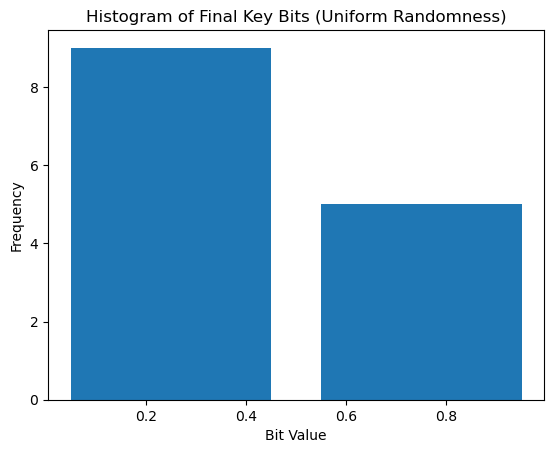

Entropy Score of Final Key: 0.940 bits (Ideal ≈ 1.0)
Key length (bits): 14
Avalanche Effect (Bit Difference Ratio): 0.571


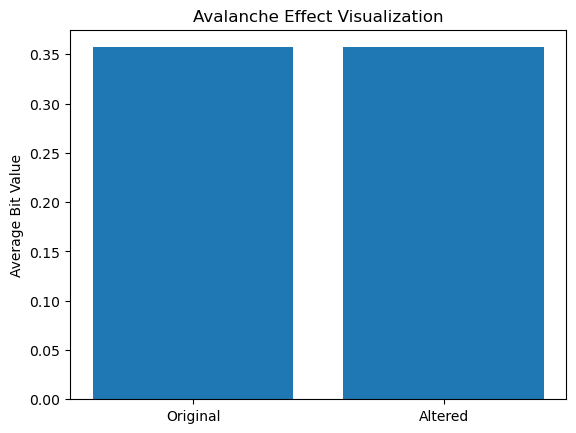

In [10]:
# ---- METRICS & VISUALIZATION ----
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from math import log2

#  Convert final key bits to array for histogram
key_array = np.array(final_key_bits)

#  Histogram of QRNG/Key Output (Uniform Randomness)
plt.hist(key_array, bins=2, rwidth=0.8)
plt.title("Histogram of Final Key Bits (Uniform Randomness)")
plt.xlabel("Bit Value")
plt.ylabel("Frequency")
plt.show()

#  Entropy Calculation (Shannon Entropy)
bit_counts = Counter(final_key_bits)
total = len(final_key_bits)
entropy = -sum((count/total) * log2(count/total) for count in bit_counts.values())
print(f"Entropy Score of Final Key: {entropy:.3f} bits (Ideal ≈ 1.0)")

#  Key length and basic info
print(f"Key length (bits): {len(final_key_bits)}")

#  Avalanche Effect Demonstration
# Slightly modify the seed to create a new permutation and key
import copy, random

random.seed(99)
np.random.seed(99)
# re-generate permutation using same key length
perm_indices = np.random.permutation(len(final_key_bits))
# Apply to key bits to simulate altered key
altered_key_bits = [final_key_bits[i] for i in perm_indices]

# Compare with original
differences = sum(1 for a, b in zip(final_key_bits, altered_key_bits) if a != b)
avalanche_ratio = differences / len(final_key_bits)
print(f"Avalanche Effect (Bit Difference Ratio): {avalanche_ratio:.3f}")

#  Plot Avalanche Difference
plt.bar(["Original", "Altered"], [np.mean(final_key_bits), np.mean(altered_key_bits)])
plt.title("Avalanche Effect Visualization")
plt.ylabel("Average Bit Value")
plt.show()
